In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri Oct 30 12:27:53 2020

@author: ifenty
"""
import os
import sys
import time
import hashlib
import json
import numpy as np
import importlib


from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
sys.path.append('/Users/ifenty/git_repo_others/ECCOv4-py')
import ecco_v4_py as ecco

# make changes to example.py file

importlib.reload(ecco)
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib as mpl

In [3]:
#sys.path.append('/Users/ifenty/git_repo_others/ECCO-ACCESS/ecco-cloud-utils')
#import ecco_cloud_utils as ea
from pathlib import Path
import pandas as pd
import netCDF4 as nc4
import xarray as xr
import datetime
from pprint import pprint
from collections import OrderedDict
import pyresample as pr
import uuid
import pickle
import matplotlib.pyplot as plt
from pandas import read_csv

In [4]:
# uses the MITgcm simplegrid package by Greg Moore and Ian Fenty
# https://github.com/nasa/simplegrid

sys.path.append('/Users/ifenty/git_repo_others/simplegrid/')
import simplegrid as sg

sys.path.append('/Users/ifenty/git_repo_others/ECCO-Dataset-Production/processing/src/utils/')
import gen_netcdf_utils as gen_netcdf_utils
importlib.reload(gen_netcdf_utils)

# Create the first step native grid geometry for V4r6

In [5]:
netcdf_filename ='pre_GRID_GEOMETRY_ECCO_V4r6_native_llc0090.nc'
output_filepath = Path('/Users/ifenty/tmp/') / netcdf_filename
print(output_filepath)

/Users/ifenty/tmp/pre_GRID_GEOMETRY_ECCO_V4r6_native_llc0090.nc


# Load Product Generation Config Yaml

In [6]:
import yaml
with open('/Users/ifenty/git_repo_others/ECCO-v4-Configurations/ECCOv4 Release 5/metadata/product_generation_config.yaml', 'r') as file:
    product_generation_config = yaml.safe_load(file)
product_generation_config.keys()

dict_keys(['create_checksum', 'read_ecco_grid_for_native_load', 'extra_prints', 'download_all_fields', 'use_workers_to_download', 'compare_checksums', 'ecco_version', 'product_version', 'array_precision', 'model_start_time', 'model_end_time', 'num_vertical_levels', 'geospatial_vertical_min', 'latlon_grid_resolution', 'latlon_effective_grid_radius', 'latlon_grid_area_extent', 'custom_grid_and_factors', 'grid_files_dir', 'custom_factors_dir', 'source_grid_min_L', 'source_grid_max_L', 'source_grid_ftype', 'target_grid_ftype', 'ecco_grid_dir', 'ecco_grid_dir_mds', 'mapping_factors_dir', 'ecco_code_name', 'ecco_code_dir', 'ecco_access_dir', 'ecco_configurations_name', 'ecco_configurations_subfolder', 'metadata_dir', 'model_output_dir', 'local_file_dir_to_upload', 'processed_output_dir_base', 'ecco_grid_filename', 'filename_tail_1D', 'filename_tail_latlon', 'filename_tail_native', 'podaac_metadata_filename', 'processing_code_filename', 'history', 'references', 'source', 'project_summary', 'd

## Define some parameters based on the product_generation_config yaml fields

In [7]:
# Define fill values for binary and netcdf based on provided array_precision
# ECCO always uses -9999 for missing data.
if product_generation_config['array_precision'] == 'float32':
    # binary_output_dtype = '>f4'
    array_precision = np.float32
    netcdf_fill_value = nc4.default_fillvals['f4']
else:
    # binary_output_dtype = '>f8'
    array_precision = np.float64
    netcdf_fill_value = nc4.default_fillvals['f8']

# num of depth levels
nk = product_generation_config['num_vertical_levels']

ecco_start_time = np.datetime64(product_generation_config['model_start_time'])
ecco_end_time   = np.datetime64(product_generation_config['model_end_time'])
        
print(f'netcdf fill values {netcdf_fill_value}')

netcdf fill values 9.969209968386869e+36


# Load ECCO Grid

## Load the core tile files

In [8]:
# grid path
ecco_grid_dir_mds = Path('/Users/ifenty/Library/CloudStorage/Box-Box/ifenty/Projects/ECCO/ECCOv4/R6/grid')

mitgrid_files = list(ecco_grid_dir_mds.glob('tile*mitgrid'))
mitgrid_tile = dict()
mitgrid_tile[1] = sg.gridio.read_mitgridfile(ecco_grid_dir_mds / 'tile001.mitgrid', 90, 270)
mitgrid_tile[2] = sg.gridio.read_mitgridfile(ecco_grid_dir_mds / 'tile002.mitgrid', 90, 270)
mitgrid_tile[3] = sg.gridio.read_mitgridfile(ecco_grid_dir_mds / 'tile003.mitgrid', 90, 90)
mitgrid_tile[4] = sg.gridio.read_mitgridfile(ecco_grid_dir_mds / 'tile004.mitgrid', 270, 90)
mitgrid_tile[5] = sg.gridio.read_mitgridfile(ecco_grid_dir_mds / 'tile005.mitgrid', 270, 90)

## Make XG YG coords that include all 4 corners of grid cells

In [9]:

XG_igjg = dict()
YG_igjg = dict()

for i in range(1,6):
    XG_igjg[i] = mitgrid_tile[i]['XG'].T
    YG_igjg[i] = mitgrid_tile[i]['YG'].T

XG_igjg_tiles = ecco.llc_ig_jg_faces_to_tiles(XG_igjg)
YG_igjg_tiles = ecco.llc_ig_jg_faces_to_tiles(YG_igjg)

llc_faces_to_tiles: data_tiles shape  (13, 91, 91)
llc_faces_to_tiles: data_tiles dtype  >f8
llc_faces_to_tiles: data_tiles shape  (13, 91, 91)
llc_faces_to_tiles: data_tiles dtype  >f8


In [10]:
# Create DataArrays for the new XGG YGG coords

igjg_coords = list(range(91))
tile_coords = list(range(13))

XGG_DA = xr.DataArray(XG_igjg_tiles, dims=["tile","j_gg","i_gg"],\
                          coords=[tile_coords, igjg_coords, igjg_coords])
XGG_DA.name = 'XGG'

YGG_DA = xr.DataArray(YG_igjg_tiles, dims=["tile","j_gg","i_gg"],\
                          coords=[tile_coords, igjg_coords, igjg_coords])
YGG_DA.name = 'YGG'

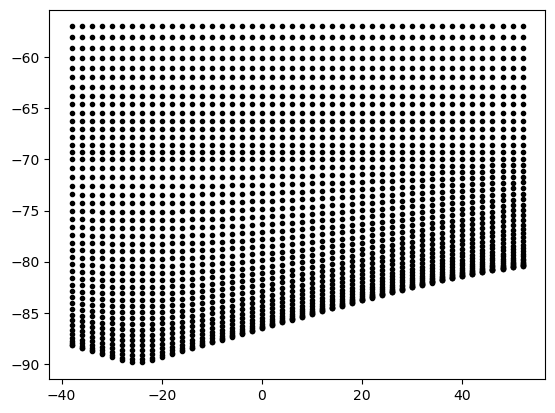

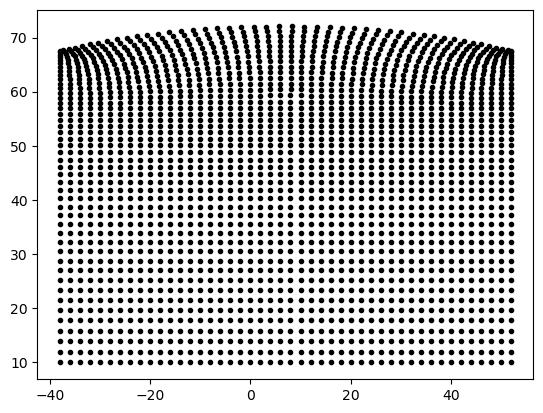

In [11]:
# plot some XGG AND YGG

plt.plot(XGG_DA[1,::2,::2],YGG_DA[0,::2,::2],'k.');
plt.figure()
plt.plot(XGG_DA[2,::2,::2],YGG_DA[2,::2,::2],'k.');


## Construct horizontal cell bounds for tracer points

In [12]:
XC_bnds = np.zeros((13,90,90,4))
YC_bnds = np.zeros((13,90,90,4))

for tile in range(13):
    XC_bnds[tile,:,:,0] = XG_igjg_tiles[tile, :-1, :-1] # --
    XC_bnds[tile,:,:,1] = XG_igjg_tiles[tile, :-1, 1:]   # -+
    XC_bnds[tile,:,:,2] = XG_igjg_tiles[tile, 1:,  1:]   # ++
    XC_bnds[tile,:,:,3] = XG_igjg_tiles[tile, 1:, :-1] # +-

    YC_bnds[tile,:,:,0] = YG_igjg_tiles[tile, :-1, :-1] # --
    YC_bnds[tile,:,:,1] = YG_igjg_tiles[tile, :-1, 1:]   # -+
    YC_bnds[tile,:,:,2] = YG_igjg_tiles[tile, 1:,  1:]   # ++
    YC_bnds[tile,:,:,3] = YG_igjg_tiles[tile, 1:, :-1] # +-

#%%
tile_coords = list(range(13))
ij_coords = list(range(90))
nbh_coords = list(range(4))

XC_bnds_DA = xr.DataArray(XC_bnds, dims=["tile","j","i","nbh"],\
                          coords=[tile_coords, ij_coords, ij_coords, nbh_coords])
YC_bnds_DA = xr.DataArray(YC_bnds, dims=["tile","j","i","nbh"],\
                          coords=[tile_coords, ij_coords, ij_coords, nbh_coords])
XC_bnds_DA.name = 'XC_bnds'
YC_bnds_DA.name = 'YC_bnds'

## Construct vertical cell bounds for tracer points

In [13]:
# Make depth bounds (top and bottom of cell)
depth_bounds = np.zeros((nk,2))

# load drF from model grid directory
tmp = ecco.load_binary_array(ecco_grid_dir_mds, 'DRF.data', ni=1,nj=1,nk=-1,skip=0,
                      filetype = '>f', less_output = False)
drF = [x[0][0] for x in tmp]
cell_bottom_depths = np.cumsum(drF)

for k in range(nk):
    if k == 0:
        # k=0, the top of the grid cell is at 0m depth
        depth_bounds[k,0] = 0.0
    else:
        # below k = 0, the top is the same as the bottom of the cell above
        depth_bounds[k,0] = -cell_bottom_depths[k-1]
    
    depth_bounds[k,1] = -cell_bottom_depths[k]
    
k_coords = list(range(50))
nbv_coords = list(range(2))
                
Z_bnds_DA = xr.DataArray(data=depth_bounds, dims=['k','nv'], \
    coords=[k_coords, nbv_coords])
Z_bnds_DA.name = 'Z_bnds'
print('\nfirst 5 levels of Z_bnds')
pprint(Z_bnds_DA[:5,:].values)

print('\nlast 5 levels of Z_bnds')
pprint(Z_bnds_DA[-5:,:].values)

load_binary_array: loading file /Users/ifenty/Library/CloudStorage/Box-Box/ifenty/Projects/ECCO/ECCOv4/R6/grid/DRF.data
load_binary_array: loading all 2D records.  nk = 50
load_binary_array: data array shape  (50, 1, 1)
load_binary_array: data array type  >f4

first 5 levels of Z_bnds
array([[  0., -10.],
       [-10., -20.],
       [-20., -30.],
       [-30., -40.],
       [-40., -50.]])

last 5 levels of Z_bnds
array([[-4082. , -4446.5],
       [-4446.5, -4834. ],
       [-4834. , -5244.5],
       [-5244.5, -5678. ],
       [-5678. , -6134.5]])


## Make Horizontal and Vertical Cell bounds DataArrays

In [14]:
# 2D
XC_YC_bnds = xr.merge([XC_bnds_DA, YC_bnds_DA])

# 3D
XC_YC_Z_bnds = xr.merge([XC_bnds_DA, YC_bnds_DA, Z_bnds_DA])

print(XC_YC_bnds)
print('\n')
print(XC_YC_Z_bnds)

<xarray.Dataset> Size: 7MB
Dimensions:  (tile: 13, j: 90, i: 90, nbh: 4)
Coordinates:
  * tile     (tile) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int64 720B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int64 720B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * nbh      (nbh) int64 32B 0 1 2 3
Data variables:
    XC_bnds  (tile, j, i, nbh) float64 3MB -115.0 -115.0 ... -115.0 -108.5
    YC_bnds  (tile, j, i, nbh) float64 3MB -88.18 -88.32 -88.3 ... -88.18 -88.16


<xarray.Dataset> Size: 7MB
Dimensions:  (tile: 13, j: 90, i: 90, nbh: 4, k: 50, nv: 2)
Coordinates:
  * tile     (tile) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int64 720B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int64 720B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * nbh      (nbh) int64 32B 0 1 2 3
  * k        (k) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * nv       (nv) int64 16B 0 1
Data variables:
   

In [15]:
Z_bnds_DA[:5,:]

<xarray.DataArray 'Z_bnds' (k: 5, nv: 2)> Size: 80B
array([[  0., -10.],
       [-10., -20.],
       [-20., -30.],
       [-30., -40.],
       [-40., -50.]])
Coordinates:
  * k        (k) int64 40B 0 1 2 3 4
  * nv       (nv) int64 16B 0 1

## Create the ecco_grid object using xmitgcm

In [16]:
# load ecco grid
print(ecco_grid_dir_mds)
ecco_grid =  ecco.load_ecco_vars_from_mds(str(ecco_grid_dir_mds),
                                    str(ecco_grid_dir_mds),
                                    '',
                                    vars_to_load = 'all',
                                    drop_unused_coords = False,
                                    grid_vars_to_coords = False,
                                    #coordinate_metadata = metadata['spatial_coordinate_metadata_for_native_datasets'],
                                    #variable_metadata = metadata['geometry_metadata_for_native_datasets'],
                                    #global_metadata = global_metadata_native,
                                    #cell_bounds = XC_YC_Z_bnds,
                                    less_output=True).load();


# save a copy here
ecco_grid_orig = ecco_grid.copy(deep=True)

# add some of our new coordinates
ecco_grid = ecco_grid.assign_coords({"XC_bnds": (("tile","j","i","nb"), XC_bnds_DA.data)})
ecco_grid = ecco_grid.assign_coords({"YC_bnds": (("tile","j","i","nb"), YC_bnds_DA.data)})
ecco_grid = ecco_grid.assign_coords({"Z_bnds": (("k","nv"), Z_bnds_DA.data)})

ecco_grid = ecco_grid.assign_coords({"XGG": (("tile","j_gg","i_gg"), XGG_DA.data)})
ecco_grid = ecco_grid.assign_coords({"YGG": (("tile","j_gg","i_gg"), YGG_DA.data)})

print('\nAfter Load')
print(ecco_grid.coords)
print(ecco_grid.data_vars)



/Users/ifenty/Library/CloudStorage/Box-Box/ifenty/Projects/ECCO/ECCOv4/R6/grid

After Load
Coordinates:
  * i        (i) int64 720B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i_g      (i_g) int64 720B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * j        (j) int64 720B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * j_g      (j_g) int64 720B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * k        (k) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * k_u      (k_u) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * k_l      (k_l) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * k_p1     (k_p1) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
  * tile     (tile) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
    XC       (tile, j, i) >f4 421kB -111.6 -111.3 -110.9 ... -105.6 -111.9
    YC       (tile, j, i) >f4 421kB -88.24 -88.38 -88.52 ... -88.03 -88.08 -88.1
    XG       (tile, j_g, i_g) >f4 421kB

In [17]:
ecco_grid

<xarray.Dataset> Size: 96MB
Dimensions:  (i: 90, i_g: 90, j: 90, j_g: 90, k: 50, k_u: 50, k_l: 50,
              k_p1: 51, tile: 13, nb: 4, nv: 2, j_gg: 91, i_gg: 91)
Coordinates: (12/22)
  * i        (i) int64 720B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i_g      (i_g) int64 720B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * j        (j) int64 720B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * j_g      (j_g) int64 720B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * k        (k) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * k_u      (k_u) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    ...       ...
    Zl       (k_l) >f4 200B 0.0 -10.0 -20.0 ... -4.834e+03 -5.244e+03 -5.678e+03
    XC_bnds  (tile, j, i, nb) float64 3MB -115.0 -115.0 -107.9 ... -115.0 -108.5
    YC_bnds  (tile, j, i, nb) float64 3MB -88.18 -88.32 -88.3 ... -88.18 -88.16
    Z_bnds   (k, nv) float64 800B 0.0 -10.0 -10.0 ... -5.678e+03 -6.134e+03
    XGG      (tile, j_gg, i_gg) >f8 861kB -115.0 -115.0 -115.0 ... -108.5 -115.0
    YGG      (tile, j_gg, i_gg) >f8 861kB -88.18 -88.32 -88.46 ... -88.16 -88.18
Dimensions without coordinates: nb, nv, j_gg, i_gg
Data variables: (12/27)
    CS       (tile, j, i) >f4 421kB 0.06158 0.06675 0.07293 ... -0.9854 -0.9984
    SN       (tile, j, i) >f4 421kB -0.9981 -0.9978 -0.9973 ... -0.1705 -0.05718
    rA       (tile, j, i) >f4 421kB 3.623e+08 3.633e+08 ... 3.685e+08 3.611e+08
    dxG      (tile, j_g, i) >f4 421kB 1.558e+04 1.559e+04 ... 2.36e+04 2.314e+04
    dyG      (tile, j, i_g) >f4 421kB 2.321e+04 2.327e+04 ... 1.56e+04 1.558e+04
    Depth    (tile, j, i) >f4 421kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    ...       ...
    dxV      (tile, j_g, i_g) >f4 421kB 1.558e+04 1.559e+04 ... 2.337e+04
    rSurfC   (tile, j, i) >f4 421kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    rLowC    (tile, j, i) >f4 421kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    dxF      (tile, j, i) >f4 421kB 1.559e+04 1.559e+04 ... 2.364e+04 2.318e+04
    dyU      (tile, j_g, i_g) >f4 421kB 1.155e+04 1.158e+04 ... 1.558e+04
    dyF      (tile, j, i) >f4 421kB 2.324e+04 2.33e+04 ... 1.559e+04 1.558e+04
Attributes:
    Conventions:             CF-1.6
    date_created:            2026-05-25T17:23:28
    date_issued:             2026-05-25T17:23:28
    date_metadata_modified:  2026-05-25T17:23:28
    date_modified:           2026-05-25T17:23:28
    history:                 Created by calling `open_mdsdataset(data_dir='/U...
    original_mds_grid_dir:   /Users/ifenty/Library/CloudStorage/Box-Box/ifent...
    original_mds_var_dir:    /Users/ifenty/Library/CloudStorage/Box-Box/ifent...
    source:                  MITgcm
    title:                   netCDF wrapper of MITgcm MDS binary data

## Examine some of our new coords

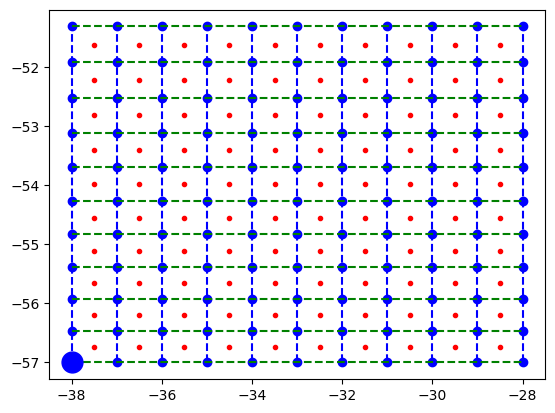

In [18]:
tile = 1

plt.plot(ecco_grid.XC[tile,:10, :10], ecco_grid.YC[tile,:10, :10], 'r.')
plt.plot(ecco_grid.XGG[tile,:11, :11], ecco_grid.YGG[tile,:11, :11], 'bo')
plt.plot(ecco_grid.XGG[tile,:11, :11], ecco_grid.YGG[tile,:11, :11], 'b--')
plt.plot(ecco_grid.XGG[tile,:11, :11].T, ecco_grid.YGG[tile,:11, :11].T, 'g--')

# the first index make big blue circle
plt.plot(ecco_grid.XGG[tile,0,0], ecco_grid.YGG[tile,0, 0], 'bo',markersize=15)

## Make new XU, YU, XV, YV coords to approximate location of fields on U and V points

(<Figure size 900x900 with 25 Axes>,
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]))

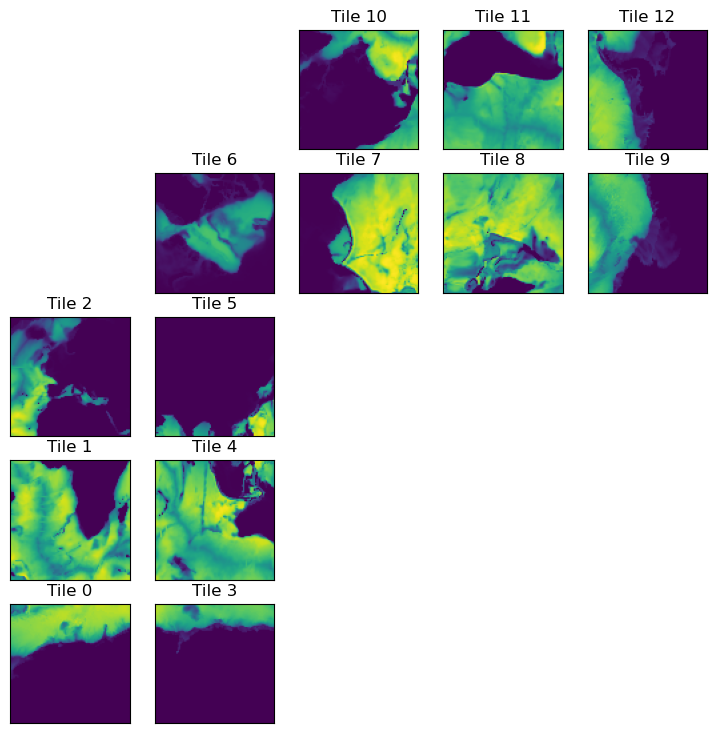

In [19]:
# for sanity checking, focus on tile 1

ecco.plot_tiles(ecco_grid.Depth)

In [20]:
# for xu, yu, average the i_g points (rows)
# for xv, yv, average the j_g points (cols)

# first xv, yv
tmp_xv = 0.5*(ecco_grid.XGG[:,:90,:-1].values + ecco_grid.XGG[:,:90,1:].values)
tmp_yv = 0.5*(ecco_grid.YGG[:,:90,:-1].values + ecco_grid.YGG[:,:90,1:].values)

# XV
XV_DA = xr.DataArray(tmp_xv, dims=["tile","j_g","i"],\
                          coords=[tile_coords, range(90), range(90)])
XV_DA.name = 'XV'

# YU
YV_DA = xr.DataArray(tmp_yv, dims=["tile","j_g","i"],\
                          coords=[tile_coords, range(90), range(90)])
YV_DA.name = 'YV'

# if 'XV' in ecco_grid.coords:
#     ecco_grid = ecco_grid.drop_vars(['XV','YV'])

# ecco_grid = xr.merge([ecco_grid, XV_DA, YV_DA])
# ecco_grid = ecco_grid.set_coords(['XV', 'YV'])

ecco_grid = ecco_grid.assign_coords({"XV": (("tile","j_g","i"), XV_DA.data)})
ecco_grid = ecco_grid.assign_coords({"YV": (("tile","j_g","i"), YV_DA.data)})


In [21]:
tmp_xu = 0.5*(ecco_grid.XGG[:,:-1,:90].values + ecco_grid.XGG[:,1:,:90].values)
tmp_yu = 0.5*(ecco_grid.YGG[:,:-1,:90].values + ecco_grid.YGG[:,1:,:90].values)

XU_DA = xr.DataArray(tmp_xu, dims=["tile","j","i_g"],\
                          coords=[tile_coords, range(90), range(90)])
XU_DA.name = 'XU'

YU_DA = xr.DataArray(tmp_yu, dims=["tile","j","i_g"],\
                          coords=[tile_coords, range(90), range(90)])
YU_DA.name = 'YU'

# if 'XU' in ecco_grid.coords:
#     ecco_grid = ecco_grid.drop_vars(['XU','YU'])

# ecco_grid = xr.merge([ecco_grid, XU_DA, YU_DA])
# ecco_grid = ecco_grid.set_coords(['XU', 'YU'])

ecco_grid = ecco_grid.assign_coords({"XU": (("tile","j","i_g"), XU_DA.data)})
ecco_grid = ecco_grid.assign_coords({"YU": (("tile","j","i_g"), YU_DA.data)})


('tile', 'j', 'i_g')
('tile', 'j_g', 'i')


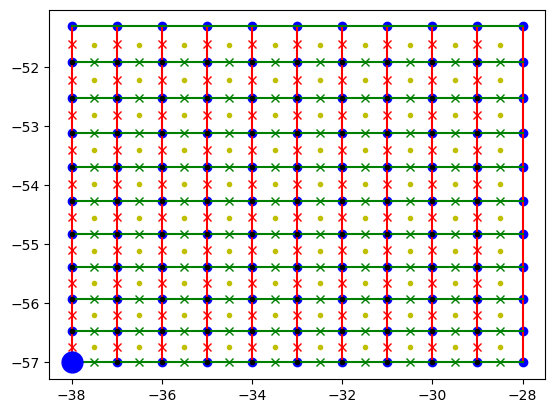

In [22]:
# show some of our new coords

plt.plot(ecco_grid.XC[1,:10, :10], ecco_grid.YC[1,:10, :10], 'y.');
plt.plot(ecco_grid.XGG[1,:11, :11], ecco_grid.YGG[1,:11, :11], 'bo');
plt.plot(ecco_grid.XGG[1,:11, :11], ecco_grid.YGG[1,:11, :11], 'r-');
plt.plot(ecco_grid.XGG[1,:11, :11].T, ecco_grid.YGG[1,:11, :11].T, 'g-');
plt.plot(ecco_grid.XG[1,:10, :10], ecco_grid.YG[1,:10, :10], 'k.');

# our new U and V point coords
plt.plot(ecco_grid.XU[1,:10, :10], ecco_grid.YU[1,:10, :10], 'rx');
plt.plot(ecco_grid.XV[1,:10, :10], ecco_grid.YV[1,:10, :10], 'gx');

# the first index make big blue circle
plt.plot(ecco_grid.XGG[1,0,0], ecco_grid.YGG[1,0, 0], 'bo',markersize=15)

print(ecco_grid.XU.dims)
print(ecco_grid.XV.dims)

# Load non-standard ice shelf/ice front parameters

In [23]:
# look at the .data fields avail
grid_files = np.sort(list(ecco_grid_dir_mds.glob('*.data')));
for gf in grid_files:
        pprint(gf.name)

'AngleCS.data'
'AngleSN.data'
'DRC.data'
'DRF.data'
'DXC.data'
'DXF.data'
'DXG.data'
'DXV.data'
'DYC.data'
'DYF.data'
'DYG.data'
'DYU.data'
'Depth.data'
'K_icefront.data'
'PHrefC.data'
'PHrefF.data'
'RAC.data'
'RAC_frac.data'
'RAS.data'
'RAW.data'
'RAZ.data'
'RC.data'
'RF.data'
'R_icefront.data'
'XC.data'
'XG.data'
'YC.data'
'YG.data'
'hFacC.data'
'hFacS.data'
'hFacW.data'
'mask2dICF.data'
'mask2dSHI.data'
'mask2dSHIICF.data'
'mask3dICF.data'
'mask3dSHI.data'
'mask3dSHIICF.data'
'maskCtrlC.data'
'maskCtrlS.data'
'maskCtrlW.data'
'rLowC.data'
'rSurfC.data'
'tilei.data'
'tileid.data'
'tilej.data'


In [24]:
# Read and plot ice draft and bathy
# ice draft given to the modle
ice_draft_bin = ecco.read_llc_to_tiles(ecco_grid_dir_mds, 'ICE_DRAFT_ICE_SHELF_CAVITY_PLUS_ICE_FRONT_LLC_0090.bin', less_output=True)

# bathy given to the model
bathy_bin = ecco.read_llc_to_tiles(ecco_grid_dir_mds, 'BATHY_ICE_SHELF_CAVITY_PLUS_ICE_FRONT_LLC_0090.bin', less_output=True)

In [25]:
R_icefront = ecco.read_llc_to_tiles(ecco_grid_dir_mds, 'R_icefront.data', less_output=True)
K_icefront = ecco.read_llc_to_tiles(ecco_grid_dir_mds, 'K_icefront.data', less_output=True)

In [26]:
# 2D ice masks
mask2dSHI = ecco.read_llc_to_tiles(ecco_grid_dir_mds, 'mask2dSHI.data', less_output=True)
mask2dICF = ecco.read_llc_to_tiles(ecco_grid_dir_mds, 'mask2dICF.data', less_output=True)
mask2dSHIICF = ecco.read_llc_to_tiles(ecco_grid_dir_mds, 'mask2dSHIICF.data', less_output=True)

# 3D ice masks
mask3dSHI = ecco.read_llc_to_tiles(ecco_grid_dir_mds, 'mask3dSHI.data',nk=50,  less_output=True)
mask3dICF = ecco.read_llc_to_tiles(ecco_grid_dir_mds, 'mask3dICF.data',nk=50,  less_output=True)
mask3dSHIICF = ecco.read_llc_to_tiles(ecco_grid_dir_mds, 'mask3dSHIICF.data', nk=50, less_output=True)
print(mask3dSHIICF.shape)

(50, 13, 90, 90)


# Add ice-shelf R,K icefront

In [27]:
# create some empty 2D and 3D float arrays

tmp_2D_DA = ecco_grid.hFacC[0].copy(deep=True) * 0.0
tmp_2D_DA.attrs = {}
tmp_2D_DA.name = ''

tmp_3D_DA = ecco_grid.hFacC.copy(deep=True) * 0.0
tmp_3D_DA.attrs = {}
tmp_3D_DA.name = ''

In [28]:
R_icefront_DA = tmp_2D_DA.copy(deep=True)
R_icefront_DA.values = R_icefront
R_icefront_DA.name = 'R_icefront'
ecco_grid['R_icefront'] = R_icefront_DA

K_icefront_DA = tmp_2D_DA.copy(deep=True)
K_icefront_DA.values = K_icefront
K_icefront_DA.name = 'K_icefront'
ecco_grid['K_icefront'] = K_icefront_DA

## Add ice-shelf masaks

In [29]:
## 2D
mask2dSHI_DA=tmp_2D_DA.copy(deep=True)
mask2dSHI_DA.values = mask2dSHI
mask2dSHI_DA.name = 'mask2dSHI'
ecco_grid['mask2dSHI'] = mask2dSHI_DA

mask2dICF_DA =tmp_2D_DA.copy(deep=True)
mask2dICF_DA.values = mask2dICF
mask2dICF_DA.name = 'mask2dICF'
ecco_grid['mask2dICF'] = mask2dICF_DA

mask2dSHIICF_DA =tmp_2D_DA.copy(deep=True)
mask2dSHIICF_DA.values = mask2dSHIICF
mask2dSHIICF_DA.name = 'mask2dSHIICF'
ecco_grid['mask2dSHIICF'] = mask2dSHIICF_DA

## 3D
mask3dSHI_DA = tmp_3D_DA.copy(deep=True)
mask3dSHI_DA.values = mask3dSHI
mask3dSHI_DA.name = 'mask3dSHI'
ecco_grid['mask3dSHI'] = mask3dSHI_DA

mask3dICF_DA = tmp_3D_DA.copy(deep=True)
mask3dICF_DA.values = mask3dICF
mask3dICF_DA.name = 'mask3dICF'
ecco_grid['mask3dICF'] = mask3dICF_DA

mask3dSHIICF_DA = tmp_3D_DA.copy(deep=True)
mask3dSHIICF_DA.values = mask3dSHIICF
mask3dSHIICF_DA.name = 'mask3dSHIICF'
ecco_grid['mask3dSHIICF'] = mask3dSHIICF_DA

ecco_grid.data_vars

Data variables:
    CS            (tile, j, i) >f4 421kB 0.06158 0.06675 ... -0.9854 -0.9984
    SN            (tile, j, i) >f4 421kB -0.9981 -0.9978 ... -0.1705 -0.05718
    rA            (tile, j, i) >f4 421kB 3.623e+08 3.633e+08 ... 3.611e+08
    dxG           (tile, j_g, i) >f4 421kB 1.558e+04 1.559e+04 ... 2.314e+04
    dyG           (tile, j, i_g) >f4 421kB 2.321e+04 2.327e+04 ... 1.558e+04
    Depth         (tile, j, i) >f4 421kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    rAz           (tile, j_g, i_g) >f4 421kB 1.799e+08 1.805e+08 ... 3.642e+08
    dxC           (tile, j, i_g) >f4 421kB 1.558e+04 1.559e+04 ... 2.341e+04
    dyC           (tile, j_g, i) >f4 421kB 1.156e+04 1.159e+04 ... 1.558e+04
    rAw           (tile, j, i_g) >f4 421kB 3.617e+08 3.628e+08 ... 3.648e+08
    rAs           (tile, j_g, i) >f4 421kB 1.802e+08 1.807e+08 ... 3.605e+08
    drC           (k_p1) >f4 204B 5.0 10.0 10.0 10.0 ... 399.0 422.0 445.0 228.2
    drF           (k) >f4 200B 10.0 10.0 10.0 10.0 

unrecognized argument  title
unrecognized argument  title
unrecognized argument  title


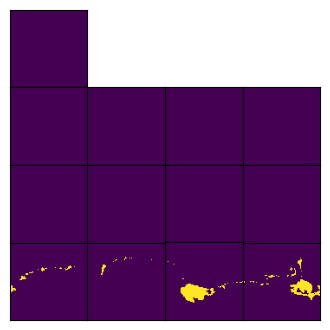

<Figure size 640x480 with 0 Axes>

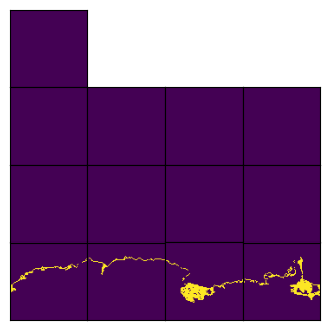

<Figure size 640x480 with 0 Axes>

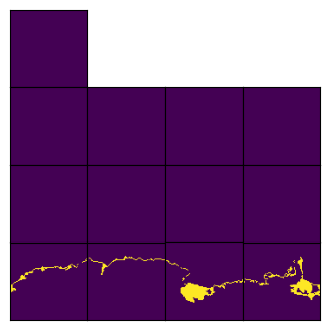

In [30]:
# plot some of these fields
ecco.plot_tiles(mask2dSHI,rotate_to_latlon=True,layout='latlon',show_tile_labels=False, title='mask2dshi',fig_size=4);

plt.figure();
ecco.plot_tiles(mask2dICF,rotate_to_latlon=True,layout='latlon',show_tile_labels=False, title='mask2dICF',fig_size=4);

plt.figure();
ecco.plot_tiles(mask2dSHIICF,rotate_to_latlon=True,layout='latlon',show_tile_labels=False, title='mask2dSHIICF',fig_size=4);

# Construct seafloor depth, ocean column thickness, and ice shelf draft

These fields can be different than what are provided to the model as input because of limits to hFacC

(<Figure size 900x906 with 16 Axes>,
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]))

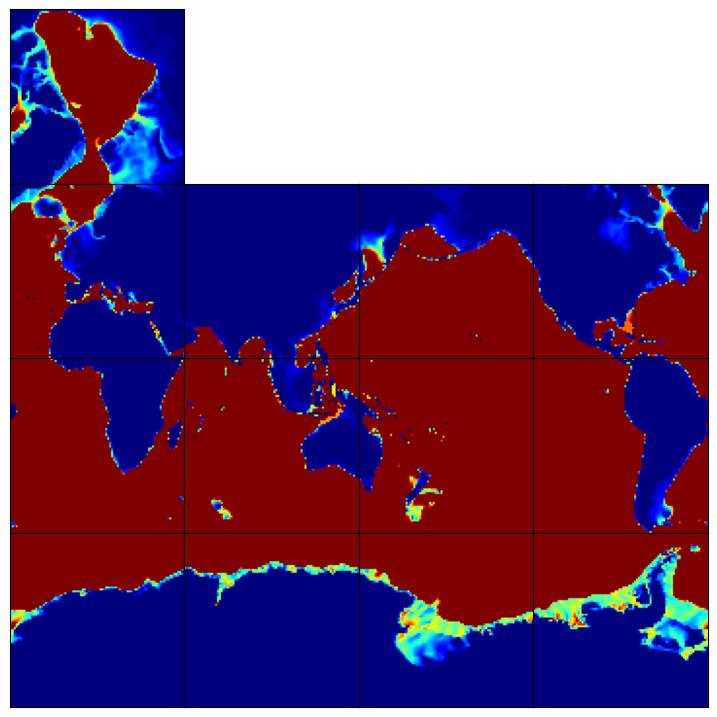

In [31]:
# Without ice shelves, the mitgcm output file called 'Depth' means the seafloor depth, 
# With ice-shelves 'Depth' is the ocean column thickness, the thickness of the wet ocean grid cells (accounting for hFacC)
# ... which mean in ice shelf cavities, it is the thickness of the cavity, not the depth of the seafloor in the cavity

# beneath ice shelves, the sea surface is at the base of the ice shelves
ecco.plot_tiles(ecco_grid.Depth, cmin=0, cmax=1000, rotate_to_latlon=True, layout='latlon', 
                show_tile_labels=False, cmap='jet', fig_size=9)

# notice the discontinuity in the in Depth at the ice-shelf edges

## Create ocean column thickness field

In [32]:
# duplicate the 'Depth' field and add it to ecco_grid as 'ocean_column_thickness'
ocean_column_thickness_DA = ecco_grid_orig.Depth.copy(deep=True);
ocean_column_thickness_DA.name = 'ocean_column_thickness'
ocean_column_thickness_DA.attrs.clear()

# add ocean column thickness to ecco_grid
ecco_grid['ocean_column_thickness'] = ocean_column_thickness_DA


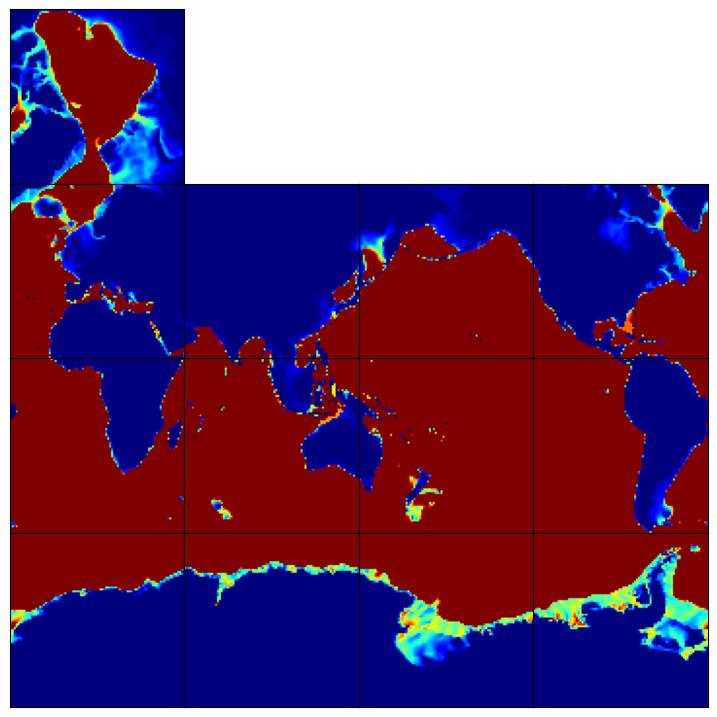

In [33]:
#ecco.plot_tiles(ecco_grid['ocean_column_thickness'],cmin=0,cmax=500)
ecco.plot_tiles(ecco_grid['ocean_column_thickness'],rotate_to_latlon=True,layout='latlon',
                show_tile_labels=False, fig_size=9, cmin=0, cmax=1000, cmap='jet');

# Ice-shelf Draft

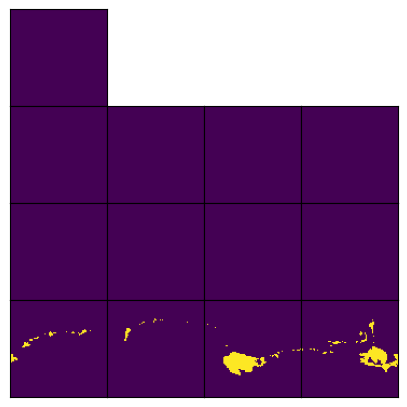

In [34]:
# the file mask2dSHI contains a mask where we have some *floating* ice shelf
# ... these are points with nonzero column thickness and surface hFacC = 0 (drop at the surface)
ecco.plot_tiles(mask2dSHI,rotate_to_latlon=True,layout='latlon',show_tile_labels=False, fig_size=5);

# mask2dSHI is a model output, let's check to see if it is what we think it is

## Masks for floating ice, grounded ice, open ocean, and land

bathy is negative
ice draft bin is negative


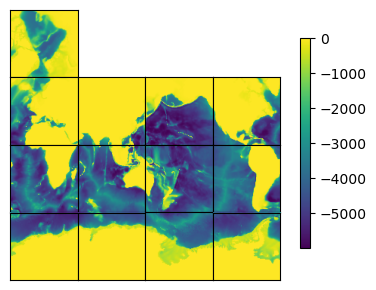

<Figure size 640x480 with 0 Axes>

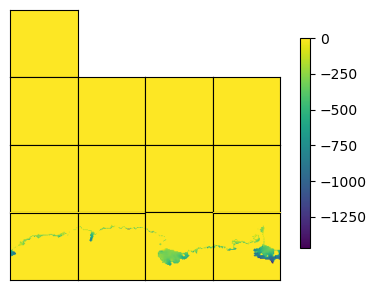

<Figure size 640x480 with 0 Axes>

In [35]:
# grounded ice points are found where ice draft is nonzero and mask2dSHI is zero

ecco.plot_tiles(bathy_bin,rotate_to_latlon=True,layout='latlon',show_tile_labels=False,
                show_colorbar=True, fig_size=4);
plt.figure();
print("bathy is negative")
ecco.plot_tiles(ice_draft_bin,rotate_to_latlon=True,layout='latlon',show_tile_labels=False,
                show_colorbar=True, fig_size=4);
plt.figure();
print("ice draft bin is negative")


In [36]:
## Make a mask that has id numbers 0,1,2,3 for points that are land, open ocean, grounded ice, floating ice shelf

# grounded points have nonzero ice draft but zero in mask2dSHI
grounded_ice_mask = np.where(np.logical_and(ice_draft_bin < 0, mask2dSHI ==0),1,0)

tmp_mask = grounded_ice_mask *0;

# floating shelf points
tmp_mask_floating = np.where(mask2dSHI == 1, 1, tmp_mask)

# surface wet points
tmp_mask_wet_surf = np.where(ecco_grid.maskC[0] == 1, 1, tmp_mask)

# grounded ice points
tmp_mask_grounded = np.where(grounded_ice_mask == 1, 1, tmp_mask)

# straight up land, no ice
tmp_mask_land = np.where(bathy_bin == 0, 1, tmp_mask)

plt.figure();
tmp_mask_all = tmp_mask_floating+ tmp_mask_wet_surf+ tmp_mask_grounded+ tmp_mask_land

# we've account for all 4 types of points, so their sum should be all ones
print(f'unique values needs to be 1 {np.unique(tmp_mask_all)}')

ocean_ice_id_mask = tmp_mask_land*0 + tmp_mask_wet_surf*1 + tmp_mask_grounded*2 + tmp_mask_floating*3 

# make an ocean ice ID mask object and add to ecco_grid
ocean_ice_id_mask_DA = tmp_2D_DA.copy(deep=True)
ocean_ice_id_mask_DA.values = ocean_ice_id_mask
ocean_ice_id_mask_DA.name = 'ocean_ice_id'
ocean_ice_id_mask_DA.values = ocean_ice_id_mask_DA.values.astype('int16')

ecco_grid['ocean_ice_id'] = ocean_ice_id_mask_DA
ocean_ice_id_mask_DA.values

ecco_grid

unique values needs to be 1 [1]


<xarray.Dataset> Size: 166MB
Dimensions:                 (i: 90, i_g: 90, j: 90, j_g: 90, k: 50, k_u: 50,
                             k_l: 50, k_p1: 51, tile: 13, nb: 4, nv: 2,
                             j_gg: 91, i_gg: 91)
Coordinates: (12/26)
  * i                       (i) int64 720B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * i_g                     (i_g) int64 720B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * j                       (j) int64 720B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * j_g                     (j_g) int64 720B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * k                       (k) int64 400B 0 1 2 3 4 5 6 ... 44 45 46 47 48 49
  * k_u                     (k_u) int64 400B 0 1 2 3 4 5 6 ... 44 45 46 47 48 49
    ...                      ...
    XGG                     (tile, j_gg, i_gg) >f8 861kB -115.0 ... -115.0
    YGG                     (tile, j_gg, i_gg) >f8 861kB -88.18 ... -88.18
    XV                      (tile, j_g, i) float64 842kB -115.0 ... -112.0
    YV                      (tile, j_g, i) float64 842kB -88.25 ... -88.03
    XU                      (tile, j, i_g) float64 842kB -111.7 ... -108.7
    YU                      (tile, j, i_g) float64 842kB -88.17 ... -88.09
Dimensions without coordinates: nb, nv, j_gg, i_gg
Data variables: (12/37)
    CS                      (tile, j, i) >f4 421kB 0.06158 0.06675 ... -0.9984
    SN                      (tile, j, i) >f4 421kB -0.9981 -0.9978 ... -0.05718
    rA                      (tile, j, i) >f4 421kB 3.623e+08 ... 3.611e+08
    dxG                     (tile, j_g, i) >f4 421kB 1.558e+04 ... 2.314e+04
    dyG                     (tile, j, i_g) >f4 421kB 2.321e+04 ... 1.558e+04
    Depth                   (tile, j, i) >f4 421kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...                      ...
    mask2dSHIICF            (tile, j, i) >f4 421kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    mask3dSHI               (k, tile, j, i) >f4 21MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    mask3dICF               (k, tile, j, i) >f4 21MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    mask3dSHIICF            (k, tile, j, i) >f4 21MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ocean_column_thickness  (tile, j, i) >f4 421kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ocean_ice_id            (tile, j, i) int16 211kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
Attributes:
    Conventions:             CF-1.6
    date_created:            2026-05-25T17:23:28
    date_issued:             2026-05-25T17:23:28
    date_metadata_modified:  2026-05-25T17:23:28
    date_modified:           2026-05-25T17:23:28
    history:                 Created by calling `open_mdsdataset(data_dir='/U...
    original_mds_grid_dir:   /Users/ifenty/Library/CloudStorage/Box-Box/ifent...
    original_mds_var_dir:    /Users/ifenty/Library/CloudStorage/Box-Box/ifent...
    source:                  MITgcm
    title:                   netCDF wrapper of MITgcm MDS binary data

<Figure size 640x480 with 0 Axes>

/var/folders/1_/d2mlmphx1y73x199m02l7_qc0000gq/T/ipykernel_64272/1260582136.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=cm.get_cmap('jet',4)


<Figure size 640x480 with 0 Axes>

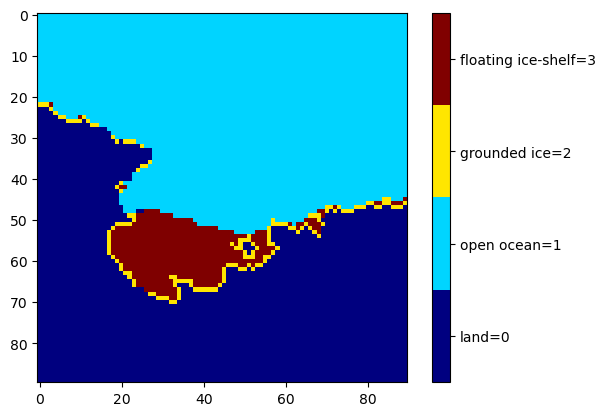

<Figure size 640x480 with 0 Axes>

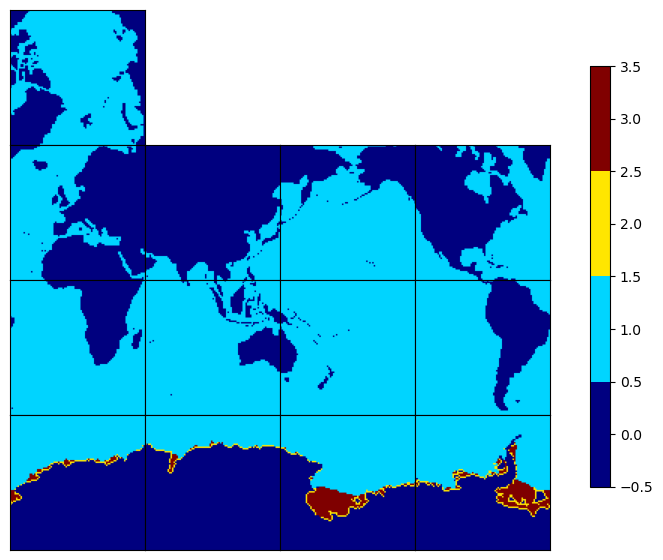

In [37]:

# plot
plt.figure();
fig, ax = plt.subplots()
cmap=cm.get_cmap('jet',4)
cax = ax.imshow(ocean_ice_id_mask[9].T, cmap=cmap,vmin=0,vmax=4);
# Add colorbar, make sure to specify tick locations to match desired ticklabels
cbar = fig.colorbar(cax, ticks=[0.5, 1.5, 2.5, 3.5])
cbar.ax.set_yticklabels(['land=0', 'open ocean=1', 'grounded ice=2','floating ice-shelf=3'])  # vertically oriented colorbarplt.colorbar()

plt.figure();

ecco.plot_tiles(ocean_ice_id_mask,rotate_to_latlon=True,layout='latlon',show_tile_labels=False,
                show_colorbar=True, fig_size=8, cmap=cmap, cmin=-.5, cmax=3.5);

In [38]:
np.unique(ocean_ice_id_mask_DA)

array([0, 1, 2, 3], dtype=int16)

# Make the model seafloor depth field

we used to get model seafloor depth from the mitgcm model output field *Depth.data*,
but *Depth.data* is ocean column thickness which is not the same as seafloor depth where there is an ice-shelf cavity

The recipe for maaking model seafloor depth is as follows
* first get the 3D model field hfacc, the open water fraction of each grid cell
* next, identify all the tile,j,i points where there is a floating ice shelf
* once we've found points with a floating ice shelf, we examine the 1D hfacc array at each of those points
* the 1D hfacc array will have a surface (k=0) value of 0, and one or more nonzero (>0) values somewhere at depth
* the nonzero values below the surface show us where the ice-shelf cavity (they are the wet fractions of grid cell thickness)
* we then identify which cell has the deepest nonzero value (call it k=kb)
* the seafloor is the k=kb grid cell because it is at the bottom of the cavity, 
* then make a copy of this 1D hfacc array at that point, hfacc_modded
* set to 1 the values of hfacc_modded from k=0 to k=kb-1 (all points *above* kb) 
* the seafloor depth is found by muliply hfacc_modded with drf and then summing

Alternatively, seafloor depth is the sum of ice-shelf draft and ocean column thickness

Where we have grounded ice, ocean column thickess iz zero, so seafloor depth is equal to ice-shelf draft from the input binary file

## ID the floating ice points

we could get it from the model's mask2dSHI

In [39]:
floating_ice_shelf_pts = np.where(mask2dSHI)
floating_ice_shelf_pts_tile = floating_ice_shelf_pts[0]
floating_ice_shelf_pts_j = floating_ice_shelf_pts[1]
floating_ice_shelf_pts_i = floating_ice_shelf_pts[2]
print(floating_ice_shelf_pts)
print(len(floating_ice_shelf_pts[0]))

(array([ 0,  0,  0, ..., 12, 12, 12]), array([32, 33, 33, ..., 89, 89, 89]), array([ 1,  0,  1, ..., 57, 58, 59]))
1139


In [40]:
# or we could get it from our own mask

floating_ice_shelf_pts_b = np.where(ecco_grid.ocean_ice_id==3)
print(floating_ice_shelf_pts_b)
print(len(floating_ice_shelf_pts_b[0]))

(array([ 0,  0,  0, ..., 12, 12, 12]), array([32, 33, 33, ..., 89, 89, 89]), array([ 1,  0,  1, ..., 57, 58, 59]))
1139


## -- ocean column thickness

ocean colum thickness is provided in the original 'Depth' field of ecco_grid

but let's double check here.

the easy way to calculate ocean column thickness is to sum hFacC *drF


(<Figure size 900x789 with 17 Axes>,
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]))

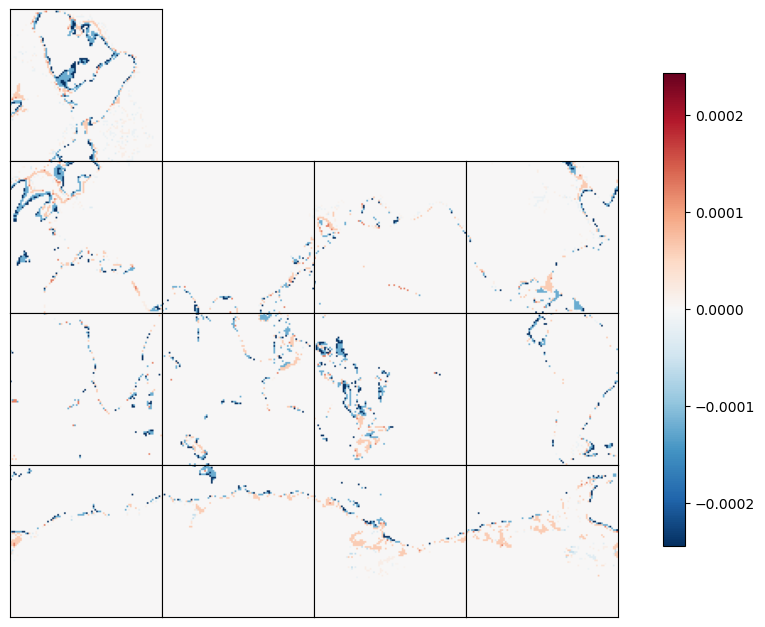

In [41]:
ocean_column_thickness = (ecco_grid_orig.hFacC * ecco_grid.drF).sum(dim='k')

# difference between what we calculate and what was provided in 'Depth'
# ... should be on the order of mm
ecco.plot_tiles(ocean_column_thickness - ecco_grid_orig['Depth'].values, show_colorbar=True, 
                layout='latlon',rotate_to_latlon=True, show_tile_labels=False)

## be obsessive, recalculate the cavity mask

find the points that are wet somewhere at depth but not at the surface, those are ice shelf cavities

<Figure size 640x480 with 0 Axes>

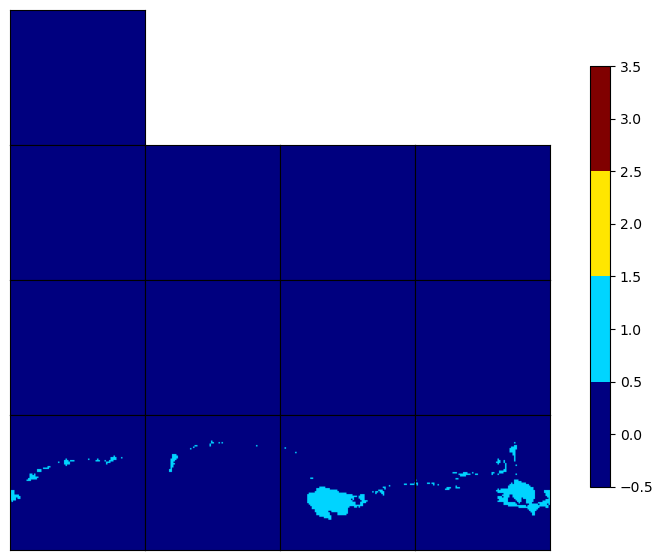

In [42]:
# wet anywhere in the column
wet_in_k = np.where(ocean_column_thickness>0, 1, 0)

# wet at the surface
dry_at_k0 = np.where(ecco_grid['maskC'][0] == True, 0, 1)

# an ice shelf cavity is where we are both
# ... dry at the surface AND
# ... wet at depth
cavity_mask = np.where(np.logical_and(dry_at_k0, wet_in_k), 1, 0)

plt.figure();

ecco.plot_tiles(cavity_mask,rotate_to_latlon=True,layout='latlon',show_tile_labels=False,
                show_colorbar=True, fig_size=8, cmap=cmap, cmin=-.5, cmax=3.5);

In [43]:
# sanity check, mask2DSHI is the same as our cavity_mask
np.unique(ecco_grid.mask2dSHI.values == cavity_mask)

array([ True])

# update "Depth" to reflect seafloor depth, not ocean cavity thickness

We also want to set the seafloor depth to be equal to the ice shelf draft where the ice is grounded
in other words, we are defining the ice at the grounding zone as being part of the ice shelf

In [44]:
# function to calculate seafloor depth and ice shelf draft

def calc_depths_beneath_floating_ice_shelf(tile, j, i, ecco_grid, debug=True):
    
    hFacC_here = ecco_grid.hFacC[:,tile, j, i] + 0
    nonzero_hFacC = np.nonzero(hFacC_here.values)[0]

    if hFacC_here[0] > 0:
        print(f'surface hFacC is nonzero, abort')
        return -1
 
    oct_here = ecco_grid.ocean_column_thickness.values[tile, j,i]
    
    if debug:
        print(f'WORKING ON (tile, j, i): {tile, j, i}')
        print(f'nonzero hFacCs #={len(nonzero_hFacC)}, {nonzero_hFacC}')
        print(hFacC_here.values[nonzero_hFacC])

    # how thick is the ice shelf?  
    # it's this thickness of all the 'dry' points from the surface down to the first 
    # partially or entirely wet point below it
    
    # to caculate ice shelf thickness we
    # ... define a 0/1 mask of length nk with initial values 0,
    # ... starting from the top (k=0), set all entirely dry (hFacC ==0) points to 1  [0:first_wet_k]
    # ... set the first partially (or entirely) wet point (at first_wet_k) to 1-hFacC[first_wet_k]
    #     --> because hFacC is the wet fraction, so 1-hFacC is the dry Fraction
    # ... then muliptly the mask by drF and sum!
    
    # this k is the first k with a nonzero hFacC.  
    first_wet_k = nonzero_hFacC[0]
    last_wet_k = nonzero_hFacC[-1]

    if first_wet_k == last_wet_k:
        print(f'the first wet k is also the last wet k, take a closer look')

    ice_shelf_tmp = np.zeros(50)
    ice_shelf_tmp[0:first_wet_k] = 1
    ice_shelf_tmp[first_wet_k] = 1-hFacC_here[first_wet_k]
    
    if debug:
        print(f'ice_shelf_tmp : {ice_shelf_tmp}')

    ice_shelf_draft_new = np.sum(ice_shelf_tmp*ecco_grid.drF.values)

    # seafloor depth is the sum of the ice shelf draft and the ocean column thickness
    seafloor_depth_new= ice_shelf_draft_new + oct_here

    if debug:
        print(f'ice_shelf_draft {ice_shelf_draft_new}')
        print(f'seafloor_depth {seafloor_depth_new}')
        #print(f'{ocean_column_thickness_new, oct_a, oct_b,np.abs(ocean_column_thickness_new - oct_b)}')
    
    return ice_shelf_draft_new, seafloor_depth_new

In [45]:
cavity_mask[9,55,55:60]

tile = 9
i = 67
j= 33
X = calc_depths_beneath_floating_ice_shelf(tile, j, i, ecco_grid, debug=True)
ice_shelf_draft_here = X[0]
seafloor_depth_here = X[1]
ocean_column_thickness_here=ecco_grid.ocean_column_thickness.values[tile,j,i]

print(f'\nPOST\nice shelf draft   {ice_shelf_draft_here}\nseafloor_depth {seafloor_depth_here}\nocean col thick {ocean_column_thickness_here}')

WORKING ON (tile, j, i): (9, 33, 67)
nonzero hFacCs #=1, [23]
[0.8067536]
the first wet k is also the last wet k, take a closer look
ice_shelf_tmp : [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         0.19324642
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]
ice_shelf_draft 528.5071443466609
seafloor_depth 592.1600030807917

POST
ice shelf draft   528.5071443466609
seafloor_depth 592.1600030807917
ocean col thick 63.65285873413086


In [46]:
np.where(cavity_mask>0)

(array([ 0,  0,  0, ..., 12, 12, 12]),
 array([32, 33, 33, ..., 89, 89, 89]),
 array([ 1,  0,  1, ..., 57, 58, 59]))

In [47]:
ice_shelf_draft_tmp = tmp_2D_DA.copy(deep=True)
ice_shelf_draft_tmp.name = 'ice_shelf_draft'

seafloor_depth_beneath_ice_shelf = tmp_2D_DA.copy(deep=True)
ice_shelf_m_tmp = tmp_2D_DA.copy(deep=True)

# three arrays: tile, j, and i
tt, tj, ti = np.where(cavity_mask>0)

for cc in range(len(tt)):
    tile = tt[cc]
    j = tj[cc]
    i = ti[cc]
    
    ice_shelf_m_tmp[tile, j,i] = 1
    
    print(f'{tile}, {j}, {i}')
    X= calc_depths_beneath_floating_ice_shelf(tile, j,i, ecco_grid, debug=False)
    
    ice_shelf_draft_tmp[tile, j, i] = X[0]
    seafloor_depth_beneath_ice_shelf[tile,j,i]= X[1]

np.unique(ice_shelf_m_tmp==cavity_mask)

# add ice shelf draft to ecco_grid
ecco_grid['ice_shelf_draft'] = ice_shelf_draft_tmp;

# add seafloor depth
# ... replace all values that are beneath floating ice shelves with our new seafloor depth
seafloor_depth = ecco_grid_orig.Depth.copy(deep=True)
seafloor_depth_new = np.where(cavity_mask==0, seafloor_depth, seafloor_depth_beneath_ice_shelf)

# update 'Depth' on ecco_grid
ecco_grid.Depth.values = seafloor_depth_new


0, 32, 1
0, 33, 0
0, 33, 1
0, 33, 2
0, 33, 3
the first wet k is also the last wet k, take a closer look
0, 34, 0
0, 34, 1
0, 34, 2
0, 34, 3
0, 34, 5
0, 34, 6
0, 35, 0
0, 35, 1
0, 35, 2
0, 35, 3
0, 35, 4
0, 35, 5
0, 35, 6
0, 36, 0
0, 36, 1
0, 36, 2
0, 36, 3
0, 36, 4
0, 36, 5
0, 37, 0
0, 37, 1
0, 37, 2
0, 38, 0
0, 38, 1
0, 38, 2
0, 39, 0
0, 39, 1
0, 39, 2
0, 46, 11
0, 46, 12
0, 46, 13
0, 47, 12
0, 47, 13
0, 47, 14
0, 47, 15
0, 47, 16
0, 47, 17
0, 48, 13
0, 48, 14
0, 48, 15
0, 48, 16
0, 48, 17
0, 48, 18
0, 49, 13
0, 49, 14
0, 49, 15
0, 49, 16
0, 50, 13
0, 50, 14
0, 50, 16
0, 52, 18
0, 52, 19
0, 52, 20
0, 53, 18
0, 53, 19
0, 53, 20
0, 54, 22
0, 54, 23
0, 54, 24
0, 54, 25
0, 55, 25
0, 55, 26
0, 56, 37
0, 57, 36
0, 57, 37
0, 57, 38
0, 57, 39
0, 57, 64
0, 58, 32
0, 58, 36
0, 58, 37
0, 58, 38
0, 58, 39
0, 58, 64
0, 58, 65
0, 58, 66
0, 59, 36
0, 59, 37
0, 59, 38
0, 59, 40
0, 59, 41
0, 59, 42
0, 59, 57
0, 59, 58
0, 59, 59
0, 59, 63
0, 59, 66
0, 59, 67
0, 59, 68
0, 60, 37
0, 60, 52
0, 60, 58
0, 6

## Update the seafloor depth at the grounding zone

In [48]:
grounded_ice_ids = np.where(ecco_grid.ocean_ice_id.values.ravel()==2)

# verify that the seafloor depth (input) and ice_draft (input)
# are identical at the grounded ice points
np.unique(bathy_bin.ravel()[grounded_ice_ids] - ice_draft_bin.ravel()[grounded_ice_ids])


array([0.], dtype=float32)

In [49]:
# set seafloor depth equal to ice draft where the ice is grounded
#ecco_grid_tmp = ecco_grid.copy(deep=True);
ecco_grid.Depth.values.ravel()[grounded_ice_ids] = -ice_draft_bin.ravel()[grounded_ice_ids]

# also set the ice shelf draft to be equal to the depth of the grounded ice at the groundingn zone
ecco_grid['ice_shelf_draft'].values.ravel()[grounded_ice_ids] = -ice_draft_bin.ravel()[grounded_ice_ids]

(<Figure size 800x701.333 with 17 Axes>,
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]))

<Figure size 640x480 with 0 Axes>

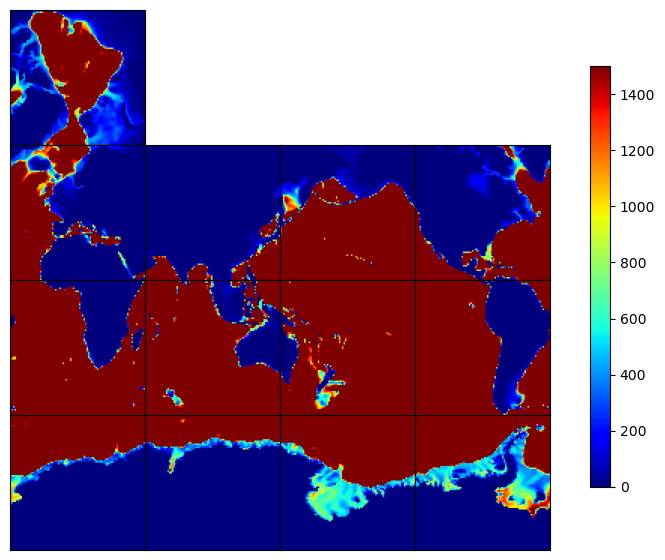

<Figure size 640x480 with 0 Axes>

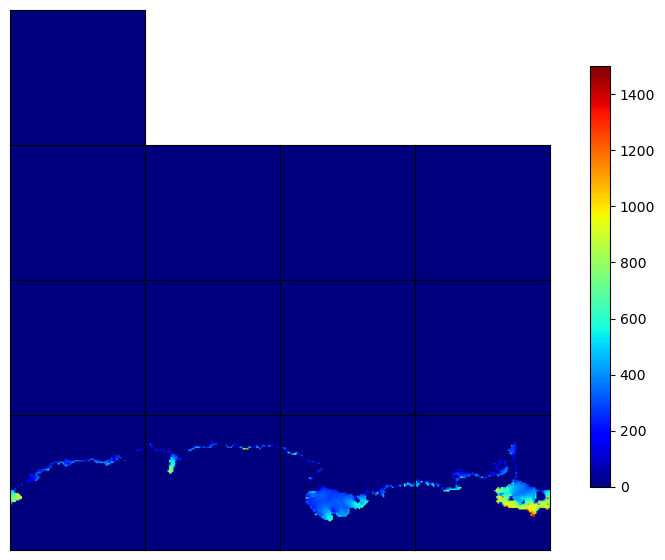

<Figure size 640x480 with 0 Axes>

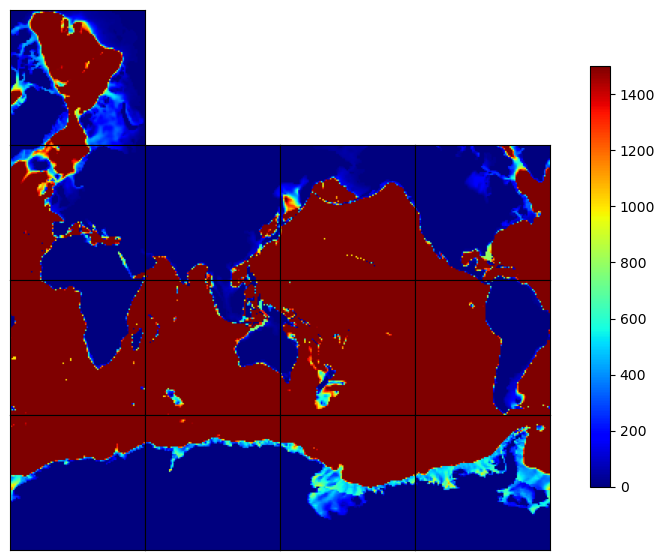

In [50]:
plt.figure();
ecco.plot_tiles(ecco_grid.Depth,rotate_to_latlon=True,layout='latlon',show_tile_labels=False,
                show_colorbar=True, fig_size=8, cmap='jet', cmin=0, cmax=1500)

plt.figure();
ecco.plot_tiles(ecco_grid.ice_shelf_draft,rotate_to_latlon=True,layout='latlon',show_tile_labels=False,
                show_colorbar=True, fig_size=8, cmap='jet', cmin=0, cmax=1500)

plt.figure();
ecco.plot_tiles(ecco_grid.ocean_column_thickness,rotate_to_latlon=True,layout='latlon',show_tile_labels=False,
                show_colorbar=True, fig_size=8, cmap='jet', cmin=0, cmax=1500)


In [51]:
# slice to investigate
tile =9
r=40
c1 = 45
c2 = 71


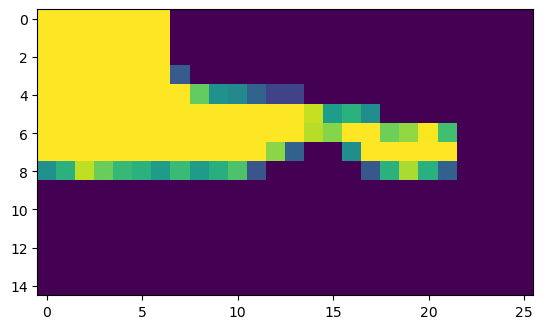

In [52]:
plt.imshow(ecco_grid.hFacC[15:30,tile,r,c1:c2])

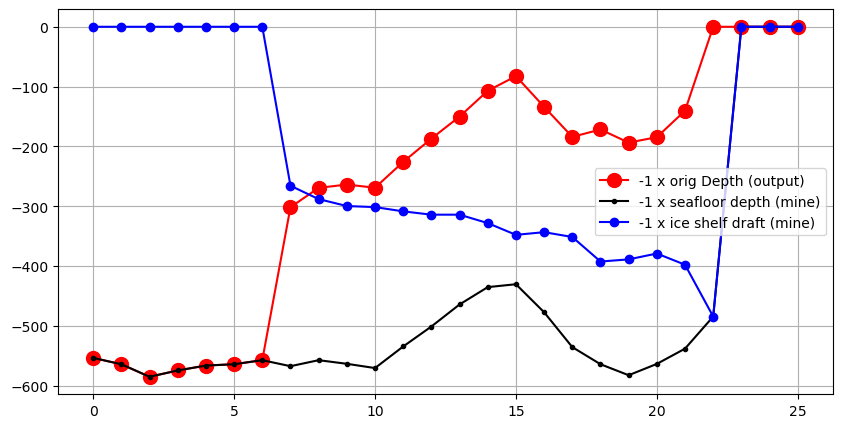

In [53]:
plt.figure(figsize=[10,5])
legends=[]
plt.plot(-ecco_grid_orig.Depth[9,r,c1:c2],'ro-',markersize=10);legends.append('-1 x orig Depth (output)')
plt.plot(-ecco_grid.Depth[9,r,c1:c2],'k.-');legends.append('-1 x seafloor depth (mine)')
plt.plot(-ecco_grid.ice_shelf_draft[9,r,c1:c2],'bo-');legends.append('-1 x ice shelf draft (mine)')

plt.legend(legends)
plt.grid()


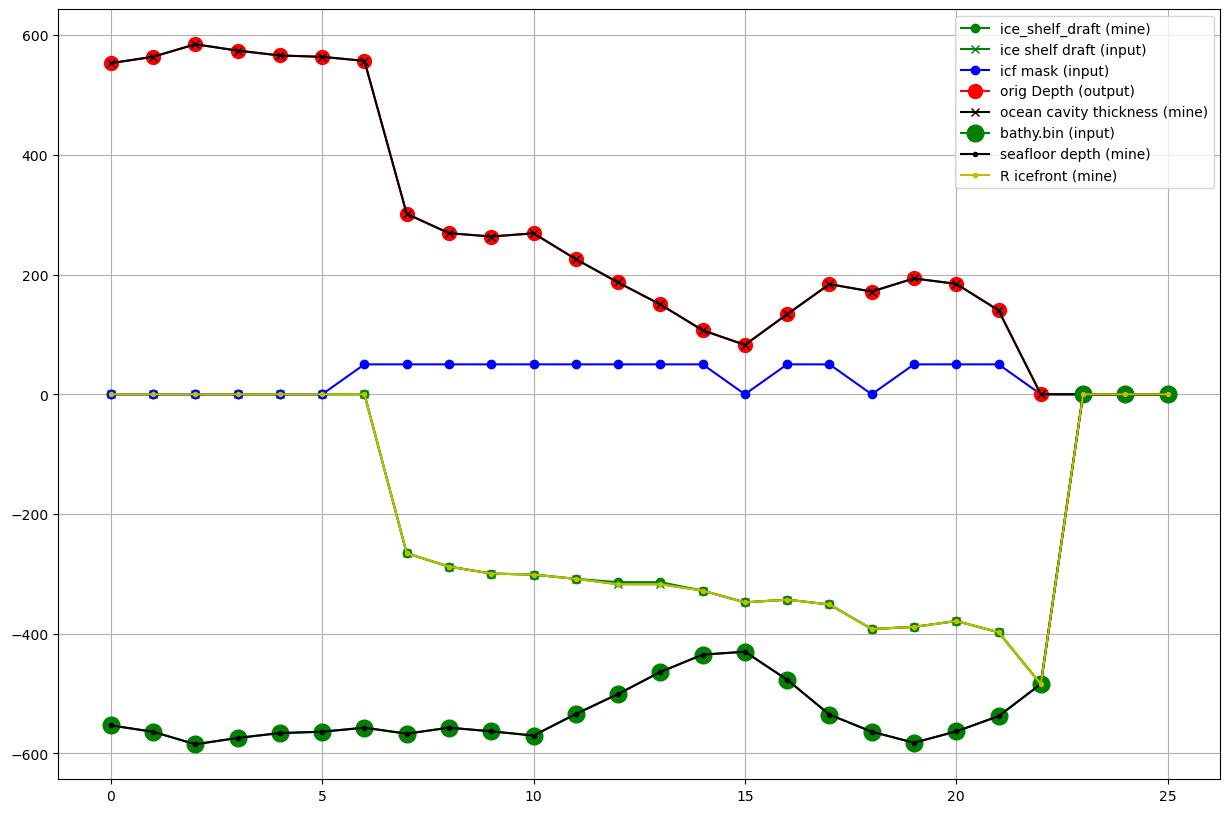

In [54]:
plt.figure(figsize=[15,10])
legends=[]
plt.plot(-ecco_grid.ice_shelf_draft[9,r,c1:c2],'go-');legends.append('ice_shelf_draft (mine)')


plt.plot(ice_draft_bin[9,r,c1:c2],'gx-');legends.append('ice shelf draft (input)')
plt.plot(ecco_grid.mask2dICF[9,r,c1:c2]*50,'bo-');legends.append('icf mask (input)')

plt.plot(ecco_grid_orig.Depth[9,r,c1:c2],'ro-',markersize=10);legends.append('orig Depth (output)')
plt.plot(ecco_grid.ocean_column_thickness[9,r,c1:c2],'kx-');legends.append('ocean cavity thickness (mine)')


plt.plot(bathy_bin[9,r,c1:c2],'go-',markersize=12);legends.append('bathy.bin (input)')
plt.plot(-ecco_grid.Depth[9,r,c1:c2],'k.-');legends.append('seafloor depth (mine)')
plt.plot(-ecco_grid.R_icefront[9,r,c1:c2],'y.-');legends.append('R icefront (mine)')
plt.legend(legends)
plt.grid()


## some more sanity checking

In [55]:
grounded_ice_ids = np.where(ecco_grid.ocean_ice_id.values.ravel()==2)[0]
print(ecco_grid_orig.Depth.values.ravel()[grounded_ice_ids[0:5]])
print(ecco_grid.Depth.values.ravel()[grounded_ice_ids[0:5]])
print(ecco_grid.ice_shelf_draft.values.ravel()[grounded_ice_ids[:5]])
print(ecco_grid.ocean_column_thickness.values.ravel()[grounded_ice_ids[:5]])
print(ecco_grid.K_icefront.values.ravel()[grounded_ice_ids[:5]])
print(ecco_grid.R_icefront.values.ravel()[grounded_ice_ids[:5]])

[0. 0. 0. 0. 0.]
[ 441.69598  678.4578   323.14175 1192.4529   833.5836 ]
[ 441.69598  678.4578   323.14175 1192.4529   833.5836 ]
[0. 0. 0. 0. 0.]
[23. 26. 20. 31. 27.]
[ 441.69598  678.4578   323.14175 1192.4529   833.5836 ]


In [56]:

floating_ice_ids = np.where(ecco_grid.ocean_ice_id.values.ravel()==3)[0]
print(ecco_grid_orig.Depth.values.ravel()[floating_ice_ids[0:5]])
print(ecco_grid.Depth.values.ravel()[floating_ice_ids[0:5]])
print(ecco_grid.ice_shelf_draft.values.ravel()[floating_ice_ids[:5]])
print(ecco_grid.ocean_column_thickness.values.ravel()[floating_ice_ids[:5]])
print(ecco_grid.K_icefront.values.ravel()[floating_ice_ids[:5]])
print(ecco_grid.R_icefront.values.ravel()[floating_ice_ids[:5]])

[172.61032 540.0109  330.70728 154.40291  74.10291]
[ 832.8903 1253.8966 1035.6805  880.766   767.49  ]
[660.28    713.8857  704.97327 726.3631  693.3871 ]
[172.61032 540.0109  330.70728 154.40291  74.10291]
[25. 26. 26. 26. 26.]
[663.08484 713.8857  704.97327 726.3631  693.3871 ]


# Add a True/False mask for any wet points in the column

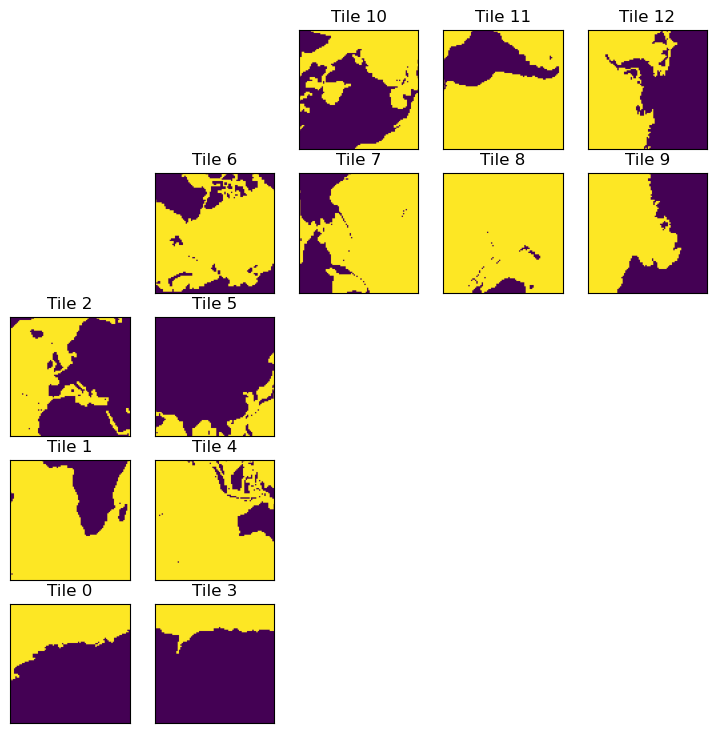

In [57]:
maskC_wet_in_k = tmp_2D_DA.copy(deep=True)
maskC_wet_in_k.values = np.where(ecco_grid.ocean_column_thickness > 0, True, False)
maskC_wet_in_k.name = 'maskC_wet_in_column'
maskC_wet_in_k.values = maskC_wet_in_k.values.astype('bool')
ecco.plot_tiles(maskC_wet_in_k)
ecco_grid['maskC_wet_in_column'] = maskC_wet_in_k

In [58]:
ecco_grid.to_netcdf(output_filepath)
ecco_grid.close()

In [59]:
output_filepath

PosixPath('/Users/ifenty/tmp/pre_GRID_GEOMETRY_ECCO_V4r6_native_llc0090.nc')

In [60]:
tmp = xr.open_dataset(output_filepath);
tmp.close();
tmp

<xarray.Dataset> Size: 166MB
Dimensions:                 (i: 90, i_g: 90, j: 90, j_g: 90, k: 50, k_u: 50,
                             k_l: 50, k_p1: 51, tile: 13, nb: 4, nv: 2,
                             j_gg: 91, i_gg: 91)
Coordinates: (12/26)
  * i                       (i) int64 720B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * i_g                     (i_g) int64 720B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * j                       (j) int64 720B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * j_g                     (j_g) int64 720B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * k                       (k) int64 400B 0 1 2 3 4 5 6 ... 44 45 46 47 48 49
  * k_u                     (k_u) int64 400B 0 1 2 3 4 5 6 ... 44 45 46 47 48 49
    ...                      ...
    XGG                     (tile, j_gg, i_gg) float64 861kB ...
    YGG                     (tile, j_gg, i_gg) float64 861kB ...
    XV                      (tile, j_g, i) float64 842kB ...
    YV                      (tile, j_g, i) float64 842kB ...
    XU                      (tile, j, i_g) float64 842kB ...
    YU                      (tile, j, i_g) float64 842kB ...
Dimensions without coordinates: nb, nv, j_gg, i_gg
Data variables: (12/39)
    CS                      (tile, j, i) float32 421kB ...
    SN                      (tile, j, i) float32 421kB ...
    rA                      (tile, j, i) float32 421kB ...
    dxG                     (tile, j_g, i) float32 421kB ...
    dyG                     (tile, j, i_g) float32 421kB ...
    Depth                   (tile, j, i) float32 421kB ...
    ...                      ...
    mask3dICF               (k, tile, j, i) float32 21MB ...
    mask3dSHIICF            (k, tile, j, i) float32 21MB ...
    ocean_column_thickness  (tile, j, i) float32 421kB ...
    ocean_ice_id            (tile, j, i) int16 211kB ...
    ice_shelf_draft         (tile, j, i) float32 421kB ...
    maskC_wet_in_column     (tile, j, i) bool 105kB ...
Attributes:
    Conventions:             CF-1.6
    date_created:            2026-05-25T17:23:28
    date_issued:             2026-05-25T17:23:28
    date_metadata_modified:  2026-05-25T17:23:28
    date_modified:           2026-05-25T17:23:28
    history:                 Created by calling `open_mdsdataset(data_dir='/U...
    original_mds_grid_dir:   /Users/ifenty/Library/CloudStorage/Box-Box/ifent...
    original_mds_var_dir:    /Users/ifenty/Library/CloudStorage/Box-Box/ifent...
    source:                  MITgcm
    title:                   netCDF wrapper of MITgcm MDS binary data

In [61]:

BUF_SIZE = 65536  # lets read stuff in 64kb chunks!

sha512 = hashlib.sha512()

with open(output_filepath, 'rb') as f:
    while True:
        data = f.read(BUF_SIZE)
        if not data:
            break
        sha512.update(data)

sha512_string = sha512.hexdigest() + '  ' + output_filepath.name + '\n'
print(sha512_string)

sha_filename = Path(str(netcdf_filename) + '.sha512')
print(sha_filename)

try:
    f = open(sha_filename, "w")
    try:
        f.write(sha512_string)
    finally:
        f.close()
except IOError:
    print ('could not write sha_fname')

6eadcd2010b1bb72e2c43c8d6db7dc08273f8b864a4eed3640d71bb4333faf9cb1a24b418ca2ac3af252270a605458bffbfebd0db8508d338fc23f246383dda0  pre_GRID_GEOMETRY_ECCO_V4r6_native_llc0090.nc

pre_GRID_GEOMETRY_ECCO_V4r6_native_llc0090.nc.sha512


In [69]:
tmp = xr.open_dataset('/Users/ifenty/tmp/GRID_GEOMETRY_ECCO_V4r6_native_llc0090.nc', mask_and_scale=False);
tmp.close()
tmp

<xarray.Dataset> Size: 160MB
Dimensions:                 (i: 90, i_g: 90, j: 90, j_g: 90, k: 50, k_u: 50,
                             k_l: 50, k_p1: 51, tile: 13, nb: 4, nv: 2,
                             j_gg: 91, i_gg: 91)
Coordinates: (12/26)
  * i                       (i) int32 360B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * i_g                     (i_g) int32 360B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * j                       (j) int32 360B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * j_g                     (j_g) int32 360B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * k                       (k) int32 200B 0 1 2 3 4 5 6 ... 44 45 46 47 48 49
  * k_u                     (k_u) int32 200B 0 1 2 3 4 5 6 ... 44 45 46 47 48 49
    ...                      ...
    XGG                     (tile, j_gg, i_gg) float32 431kB ...
    YGG                     (tile, j_gg, i_gg) float32 431kB ...
    XV                      (tile, j_g, i) float32 421kB ...
    YV                      (tile, j_g, i) float32 421kB ...
    XU                      (tile, j, i_g) float32 421kB ...
    YU                      (tile, j, i_g) float32 421kB ...
Dimensions without coordinates: nb, nv, j_gg, i_gg
Data variables: (12/39)
    CS                      (tile, j, i) float32 421kB ...
    SN                      (tile, j, i) float32 421kB ...
    rA                      (tile, j, i) float32 421kB ...
    dxG                     (tile, j_g, i) float32 421kB ...
    dyG                     (tile, j, i_g) float32 421kB ...
    Depth                   (tile, j, i) float32 421kB ...
    ...                      ...
    mask3dICF               (k, tile, j, i) float32 21MB ...
    mask3dSHIICF            (k, tile, j, i) float32 21MB ...
    ocean_column_thickness  (tile, j, i) float32 421kB ...
    ocean_ice_id            (tile, j, i) int32 421kB ...
    ice_shelf_draft         (tile, j, i) float32 421kB ...
    maskC_wet_in_column     (tile, j, i) bool 105kB ...
Attributes: (12/61)
    acknowledgement:                   This research was carried out by the J...
    author:                            Ian Fenty, Ou Wang, Ichiro Fukumori
    cdm_data_type:                     Grid
    comment:                           Fields provided on the curvilinear lat...
    Conventions:                       CF-1.8, ACDD-1.3
    coordinates_note:                  The 'coordinates' attribute lists a su...
    ...                                ...
    references:                        Fenty, I., Fukumori, I., Wang, O., For...
    source:                            The ECCO V4r6 state estimate was produ...
    standard_name_vocabulary:          NetCDF Climate and Forecast (CF) Metad...
    summary:                           This dataset provides geometric parame...
    title:                             ECCO Geometry Parameters - llc90 Grid ...
    uuid:                              2db994b2-589a-11f1-854f-8af43ebf959f

# ==============================================================================================================================================================================================================================================================================================================================================================

## Old stuff


G

for dv in G.data_vars:
    pprint(dv);
    pprint(G[dv].attrs)
    print('\n')

#metadata_json_dir = Path(product_generation_config['metadata_dir'])

metadata_json_dir = Path('/Users/ifenty/git_repo_others/ECCO-v4-Configurations/ECCOv4 Release 6/metadata')
metadata_files = np.sort(list(metadata_json_dir.glob('*json')))

# load each metadata json
metadata = dict()
for f in metadata_files:
    #print(f, f.stem)
    with open(f, 'r') as fp:
        metadata[f.stem] = json.load(fp)

# print all the metadata names
pprint(list(metadata.keys()))

# no idea why these are merged
variable_metadata_native = metadata['variable_metadata'] + metadata['geometry_metadata_for_native_datasets']

# merge metadata together into a single unholy beast
all_metadata = {'var_native': variable_metadata_native, 
                'var_latlon': metadata['variable_metadata_for_latlon_datasets'], 
                'coord_native': metadata['spatial_coordinate_metadata_for_native_datasets'], 
                'coord_latlon': metadata['spatial_coordinate_metadata_for_latlon_datasets'], 
                'global_all': metadata['global_metadata_for_all_datasets'], 
                'global_native': metadata['global_metadata_for_native_datasets'], 
                'global_latlon': metadata['global_metadata_for_latlon_datasets'],
                'geometry_native': metadata['geometry_metadata_for_native_datasets'],
                'geometry_latlon': metadata['geometry_metadata_for_latlon_datasets'],
                'groupings_1D': metadata['groupings_for_1D_datasets'],
                'groupings_native': metadata['groupings_for_native_datasets'],
                'groupings_latlon': metadata['groupings_for_latlon_datasets'],
                'coord_time': metadata['time_coordinate_metadata']}

global_metadata_native = metadata['global_metadata_for_all_datasets'] + metadata['global_metadata_for_native_datasets']

# ========== <Metadata setup> =============================================================
# Define tail for dataset description (s
dataset_description_tail_1D = product_generation_config['dataset_description_tail_1D']
dataset_description_tail_native = product_generation_config['dataset_description_tail_native']
dataset_description_tail_latlon = product_generation_config['dataset_description_tail_latlon']

processed_output_dir_base = Path(product_generation_config['processed_output_dir_base'])
#product_generation_config['mapping_factors_dir'] = Path(product_generation_config['mapping_factors_dir'])

extra_prints=True

product_type='native'
# ========== <Native/Latlon setup> ========================================================
if extra_prints: print('\nproduct type', product_type)

if product_type == 'native':
    dataset_description_tail = dataset_description_tail_native
    groupings = all_metadata['groupings_native']
    output_dir_type = processed_output_dir_base / 'native'
elif product_type == 'latlon':
    dataset_description_tail = dataset_description_tail_latlon
    groupings = all_metadata['groupings_latlon']
    output_dir_type = processed_output_dir_base / 'lat-lon'

metadata['global_metadata_for_all_datasets'];

seafloor_depth = ecco_grid.Depth.copy(deep=True)*-1
ice_shelf_depth = ecco_grid.Depth.copy(deep=True)*0
seafloor_depth.name = 'model ice-shelf depth'
ice_shelf_depth.name = 'model seafloor depth depth'
ocean_cavity_thickness_B = seafloor_depth *0

for p in range(len(floating_ice_shelf_pts_tile)):
#    print(f'P={p}')
    tile = floating_ice_shelf_pts_tile[p]
    j = floating_ice_shelf_pts_j[p]
    i = floating_ice_shelf_pts_i[p]


    debug = False
        
    hfacc_here = ecco_grid_orig.hFacC[:, tile,j,i].copy(deep=True)
    tmp_sum = hfacc_here*ecco_grid_orig.drF

    ocean_cavity_thickness_B[tile,j,i] = -tmp_sum.sum()

    if tile ==9 and j==25:
        debug = True;
        print(tile,j,i)
        
    if debug:
        print(f'orig hfacc here \n{hfacc_here.values}')

    # find the first and last nonzero value
    first_nonzero_k = np.where (hfacc_here > 0)[0][0]
    last_nonzero_k = np.where (hfacc_here > 0)[0][-1]
    
    if debug:
        print(f'\nfirst_nonzo_k {first_nonzero_k} \nlast_nonzero_k {last_nonzero_k}\nhfacc there {hfacc_here[last_nonzero_k].values}')

    hfacc_here_mod = hfacc_here + 0
    hfacc_here_mod[0:last_nonzero_k]=1

    if debug:
        print(f'\nmodded hfacc here \n{hfacc_here_mod.values}')

    tmp = hfacc_here_mod*ecco_grid_orig.drF
    tmp_sum = tmp.sum()
    if debug:
        print(f'\nnew seafloor depth = sum of drf*mhfac_here_mod = {tmp_sum.values}\n ')    

    seafloor_depth[tile,j,i] = -tmp_sum
    
#    now we'll look at the floating ice part
    hfacc_here_mod2 = hfacc_here + 0
    hfacc_here_mod2[first_nonzero_k+1:] = np.nan
    hfacc_here_mod2 = 1-hfacc_here_mod2
    tmp = hfacc_here_mod2*ecco_grid_orig.drF
    tmp_sum = tmp.sum()
    
    if debug:
        print(f'\nmodded hfacc2 here \n{hfacc_here_mod2.values}')

    ice_shelf_depth[tile,j,i] = tmp_sum;
    if debug:
        print(f'\nnew ice shelf depth = sum of drf*modded hfacc2 = {tmp_sum.values}')    
        print(f'orig ice shelf depth = {-ice_draft_bin[tile,j,i]}')
        print('\n')

seafloor_depth_DA = tmp_2D_DA.copy(deep=True)
seafloor_depth_DA.values = seafloor_depth.values
seafloor_depth_DA.name = 'Depth'
ecco_grid['Depth'] = seafloor_depth

ice_shelf_depth_DA = tmp_2D_DA.copy(deep=True)
ice_shelf_depth_DA.values = ice_shelf_depth.values
ice_shelf_depth_DA.name = 'ice_shelf_depth'
ecco_grid['ice_shelf_depth'] = ice_shelf_depth_DA

ocean_column_thickness = (ecco_grid_orig.hFacC * ecco_grid.drF).sum(dim='k')
ecco_grid['ocean_column_thickness'] = ocean_column_thickness


ecco.plot_tiles(ecco_grid.Depth, rotate_to_latlon=True, layout='latlon', cmap='jet', cmin=-500,cmax=0, show_colorbar=True)
plt.figure();

ecco.plot_tiles(ecco_grid.ice_shelf_depth, rotate_to_latlon=True, layout='latlon', cmap='jet', cmin=0,cmax=500, show_colorbar=True)

plt.figure();
ecco.plot_tiles(ecco_grid.ocean_column_thickness, rotate_to_latlon=True,
                layout='latlon', cmap='jet', cmin=0,cmax=500, show_colorbar=True)

tmp = ecco_grid.Depth + ecco_grid.ice_shelf_depth + ecco_grid.ocean_column_thickness
print(f'max, min tmp: {np.max(tmp)}, {np.min(tmp)}')
plt.figure();
ecco.plot_tiles(tmp, rotate_to_latlon=True,
                layout='latlon', cmap='jet', cmin=-1,cmax=1, show_colorbar=True)

#ecco.plot_tiles(-ecco_grid.Depth,show_colorbar=True, cmin=-1000);
#plt.plot(-ecco_grid_orig.Depth[9,40,40:80],'r-')

c1=50
c2=70

r = 40
tmp_d = np.where(ice_draft_bin != 0, 100, np.nan)

plt.figure(figsize=[15,10])
legends=[]

plt.plot(bathy_bin[9,r,c1:c2],'rx-');legends.append('bathy_bin (input)')
plt.plot(ice_draft_bin[9,r,c1:c2],'go-');legends.append('ice_draft_bin (input)')
plt.plot(tmp_d[9,r,c1:c2],'k.-');legends.append('nonzero ice draft')
plt.grid()

plt.legend(legends)

plt.figure(figsize=[15,10])
legends=[]
plt.plot(seafloor_depth[9,r,c1:c2],'bo-',markersize=5);legends.append('seafloor_depth (mine)')
plt.plot(-ecco_grid.Depth[9,r,c1:c2],'ro-');legends.append('Depth.data (output)')

#plt.plot(-ice_shelf_cavity_thickness[9,r,:80],'yo');legends.append('ice_shelf_cavity_thickness (mine)')
plt.plot(tmp_d[9,r,c1:c2],'k.-');legends.append('nonzero ice draft')
plt.plot(-ice_shelf_depth[9,r,c1:c2],'g.-');legends.append('ice_shelf_depth')
plt.plot(ocean_cavity_thickness_B[9,r,c1:c2],'yx-');legends.append('ocean cavity thickness b')
#plt.plot(mask2dSHI[9,r,:80:]*50,'kx-');legends.append('mask2dSHI')

#plt.plot(np.where(K_icefront[9,r,:80]>0,100,np.nan),'ko');legends.append('K_icefront')
plt.legend(legends)
plt.grid()
#plt.legend(['bathy','ice_draft'])
#plt.legend(legends)

plt.figure(figsize=[15,5])
legends=[]
tmp = ice_draft_bin - bathy_bin
tmp = np.where(ice_draft_bin != 0, tmp, 0)
plt.plot((tmp)[9,r,c1:c2],'go-');legends.append('ice_draft_bin where nonzero')
plt.legend(legends)

ecco.plot_tiles(ecco_grid['Depth'],cmax=1000,rotate_to_latlon=True,
                layout='latlon',show_tile_labels=False,show_colorbar=True);
plt.figure()

ice_shelf_cavity_thickness = ecco_grid['Depth']-ecco_grid_orig.Depth
ecco.plot_tiles(ice_shelf_cavity_thickness,rotate_to_latlon=True,cmax=500,
                layout='latlon',show_tile_labels=False, show_colorbar=True);

ocean_column_thickness = (ecco_grid_orig.hFacC * ecco_grid_orig.drF).sum(dim='k')
plt.figure(figsize=[5,5])
ecco.plot_tiles(ocean_column_thickness,cmax=1000,rotate_to_latlon=True,layout='latlon',show_tile_labels=False);

plt.figure(figsize=[5,5])
ecco.plot_tiles(ocean_column_thickness-ecco_grid_orig.Depth,rotate_to_latlon=True,layout='latlon',
                show_tile_labels=False, show_colorbar=True)

tmp = np.where(ice_draft_bin == bathy_bin,1,0)
tmp = np.where(bathy_bin != 0, tmp, 0)
plt.imshow(tmp[9,])

ecco_grid

ocean_column_thickness_max = ecco_grid['ocean_column_thickness'].max()
ocean_column_thickness_max.values

ice_shelf_draft_max = ecco_grid['ice_shelf_draft'].max()
ice_shelf_draft_max.values